In [1]:
import numpy as np
import xarray as xr


from pyrte_rrtmgp.rrtmgp.data_files import (
    CloudOpticsFiles,
    GasOpticsFiles,
)
# from pyrte_rrtmgp.examples import (
#     compute_RCE_clouds,
#     compute_RCE_profiles,
#     load_example_file,
#     ALLSKY_EXAMPLES,
# )
from pyrte_rrtmgp import rte
from pyrte_rrtmgp.rrtmgp import GasOptics, CloudOptics

# I need Ozone statistics - I try to obtain it from the RCEMIP data
from pyrte_rrtmgp.examples import RFMIP_FILES, load_example_file


build a ozone profile starting from the RCEMIP examples offered here

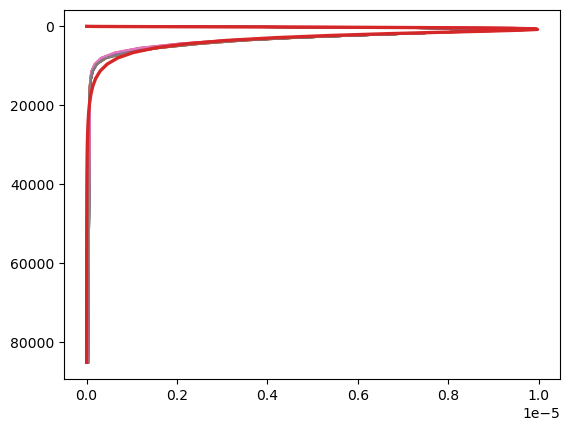

In [2]:
atmosphere_ozone = load_example_file(RFMIP_FILES.ATMOSPHERE)
ozone = atmosphere_ozone.ozone

import matplotlib.pyplot as plt
o3 = ozone.isel(site=0)
pr = atmosphere_ozone.pres_layer.isel(site=0)

for i in range(18):
    plt.plot(o3.isel(expt=i), pr)

o3_fit = 1e-5 * np.exp( -(np.log10(pr) - 2.87 )**2 / (2*0.2) )
plt.plot( o3_fit, pr, "tab:red", linewidth=2.4 )

plt.gca().invert_yaxis()
# plt.yscale('log')
# plt.ylim(100e2, 0)


# print(f"minimum pressure reached during eureca = {ds_eureca_bco_rad.p.min().item()}" )
# print(f"minimum pressure reached during orcestra = {ds_orcestra_bco_rad.p.min().item()}" )

In [3]:
# sunrise: 10 UTC
# sunset: 23 UTC
def mu0_(h):
    return xr.where(
        (h >= 22) | (h <= 10),
        0,
        np.cos(2 * np.pi * (h - 16) / 24.)
    )



def ozone_with_pressure(pr):
    """
    pressure in Pa

    returns:
    ozone profile in mol fraction
    """
    return 1e-5 * np.exp( -(np.log10(pr) - 2.87 )**2 / (2*0.2) )

def make_atmosphere(radiosounding, sst_in):
    "radiosounding should have dimensions:"
    "- column : aka time"
    "- level : actual recording height of the sonde"

    "sst should have dimension column instead of time"

    ## broadcast sst to be the same 
    ## for every day of the radiosoundings
    rs_dates = radiosounding.column.dt.floor("D")
    sst_dates = sst_in.column.dt.floor("D")

    # Keep only days present in both
    common_days = np.intersect1d(rs_dates.values, sst_dates.values)

    rs = radiosounding.sel(column=rs_dates.isin(common_days))
    sst = sst_in.sel(column=sst_dates.isin(common_days))

    # Create a daily SST lookup
    sst_daily = (
    sst.assign_coords(day=sst.column.dt.floor("D"))
       .swap_dims({"column": "day"})
       .drop_vars("column")
)

    sfc_temp = sst_daily.reindex(day=rs.column.dt.floor("D").values)
    sfc_temp = sfc_temp.rename(day="column")
    sfc_temp = sfc_temp.assign_coords(column=rs.column)

    sfc_temp.name = "surface_temperature"
    # sfc_temp = sfc_temp.reset_index(["column"])

    ## compute the other variables Im interested in
    t, p, q = rs.ta, rs.p, rs.q

    # compute air density
    Rd = 287.
    rho = p / (Rd * t*(1+0.61*q) ) 

    t.name, p.name, rho.name = "temp_level", "pres_level", "rho_a"


    # turn the output into dataArrays
    t_layer = xr.DataArray(
    0.5 * (t.data[:, :-1] + t.data[:, 1:]),
    dims=("column", "layer"),
    coords={
        # "column": t.column,
        "layer": 0.5 * (t.level.data[:-1] + t.level.data[1:]),
    },
    name="temp_layer",
    )

    p_layer = xr.DataArray(
        0.5 * (p.data[:, :-1] + p.data[:, 1:]),
        dims=("column", "layer"),
        coords={
            "column": p.column,
            "layer": 0.5 * (p.level.data[:-1] + p.level.data[1:]),
        },
        name="temp_layer",
    )

    q_layer = xr.DataArray(
        0.5 * (q.data[:, :-1] + q.data[:, 1:]),
        dims=("column", "layer"),
        coords={
            "column": q.column,
            "layer": 0.5 * (q.level.data[:-1] + q.level.data[1:]),
        },
        name="h2o",
    )


    o3 = ozone_with_pressure(p_layer)
    o3.name = "o3"


    ## compute cosine of zenith angle
    mu0 = mu0_(radiosounding.column.dt.hour)
    mu0.name = "cosine_zenith"


    atmosphere = xr.Dataset(
        data_vars={
            "temp_level": t,
            "pres_level": p,
            "temp_layer": t_layer,
            "pres_layer": p_layer,
            "h2o": q_layer,
            "rho_level": rho,
            "surface_temperature": sfc_temp,
            "o3": o3,
            "mu0": mu0
        }
    )


    # Add other gas values
    gas_values = {
        "co2": 348e-6,
        "ch4": 1650e-9,
        "n2o": 306e-9,
        "n2": 0.7808,
        "o2": 0.2095,
        "co": 0.0,
    }

    for gas_name, value in gas_values.items():
        atmosphere[gas_name] = value

    return atmosphere

load profiles

In [10]:
min_hgt = 40.

level2_path = "/work/mh1498/m301248/TCO_data/eurec4a_profiles_level2/EUREC4A_BCO_Vaisala-RS_L2_v3.0.0.nc"
ds_eureca = xr.open_dataset(level2_path)
ds_eureca_bco = ds_eureca.where(((ds_eureca["platform"] == 1)&(ds_eureca["ascent_flag"]==1)&(ds_eureca.alt>min_hgt)), drop=True)
## renaming for common ground
ds_eureca_bco = ds_eureca_bco.swap_dims({"sounding": "launch_time"})
ds_eureca_bco = ds_eureca_bco.rename({"alt":"height"})

ds_eureca_bco_rad = ds_eureca_bco.copy().rename({"launch_time":"column", "height":"level"}).sel(level=slice(0, 22000))
ds_eureca_bco_rad = ds_eureca_bco_rad.drop_vars(["sounding", "flight_time", "lat", "lon"])


ds_orcestra = xr.open_dataset("ipfs://bafybeid7cnw62zmzfgxcvc6q6fa267a7ivk2wcchbmkoyk4kdi5z2yj2w4", engine="zarr")
ds_orcestra_bco = ds_orcestra.where(((ds_orcestra["platform"] == "BCO")&(ds_orcestra["ascent_flag"]==0)&(ds_orcestra.height>min_hgt)), drop=True)
ds_orcestra_bco_rad = ds_orcestra_bco.copy().rename({"height":"level"}).sel(level=slice(0, 22000))
ds_orcestra_bco_rad = ds_orcestra_bco_rad.rename({"launch_time":"column"}).drop_vars(["interpolated_time", "lat", "lon"])



In [11]:
ingr_eu = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/EUREC4A_IngrFlux.nc")
sst_eu = ingr_eu.sst.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell"]).rename({"time":"column"}).drop_vars("alt")

ingr_or = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/ORCESTRA_IngrFlux.nc")
sst_or = ingr_or.sst.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell"]).rename({"time":"column"}).drop_vars("alt")

In [ ]:
atmosphere = make_atmosphere(ds_eureca_bco_rad.dropna(dim="column", how="any"), sst_eu)
atmosphere   #.drop_vars(["column", "level"])

<xarray.Dataset> Size: 8MB
Dimensions:              (level: 2196, column: 137, layer: 2195)
Coordinates:
  * level                (level) int16 4kB 50 60 70 80 ... 21980 21990 22000
  * column               (column) datetime64[ns] 1kB 2020-01-16T20:53:46 ... ...
  * layer                (layer) float64 18kB 55.0 65.0 ... -1.077e+04
Data variables: (12/15)
    temp_level           (column, level) float32 1MB 299.5 299.4 ... 209.6 209.8
    pres_level           (column, level) float32 1MB 1.01e+05 ... 3.985e+03
    temp_layer           (column, layer) float32 1MB 299.4 299.3 ... 209.5 209.7
    pres_layer           (column, layer) float32 1MB 1.009e+05 ... 3.988e+03
    h2o                  (column, layer) float32 1MB 0.01534 ... 3.033e-06
    rho_level            (column, level) float32 1MB 1.164 1.163 ... 0.06619
    ...                   ...
    co2                  float64 8B 0.000348
    ch4                  float64 8B 1.65e-06
    n2o                  float64 8B 3.06e-07
    n2                   float64 8B 0.7808
    o2                   float64 8B 0.2095
    co                   float64 8B 0.0

compute gas optics

In [14]:
gas_optics_lw = GasOptics(
    gas_optics_file=GasOpticsFiles.LW_G256
)

gas_optics_sw = GasOptics(
    gas_optics_file=GasOpticsFiles.SW_G224
)

In [ ]:
# atm_no_coords = (
#     atmosphere
#     .dropna(dim="column", how="all")
#     .dropna(dim="level", how="all")
#     .dropna(dim="layer", how="all")
# )

# # mask_level = atm_no_coords.pres_level >= 50000.
# # mask_layer = atm_no_coords.pres_layer >= 50000.

# # atm_no_coords = atm_no_coords.where(mask_layer & mask_level, drop=True)

In [ ]:
optical_props_lw = gas_optics_lw.compute(
    atmosphere.drop_vars(["level", "column", "layer"]), 
    add_to_input=False,
)
optical_props_lw["surface_emissivity"] = 0.98
optical_props_lw



<xarray.Dataset> Size: 2GB
Dimensions:                  (column: 137, gpt: 256, layer: 2195, level: 2196,
                              bnd: 16, pair: 2)
Coordinates:
  * column                   (column) int64 1kB 0 1 2 3 4 ... 133 134 135 136
  * gpt                      (gpt) int64 2kB 0 1 2 3 4 5 ... 251 252 253 254 255
Dimensions without coordinates: layer, level, bnd, pair
Data variables:
    surface_source           (gpt, column) float64 281kB 0.6579 ... 3.014e-06
    layer_source             (layer, gpt, column) float64 616MB 0.6544 ... 1....
    level_source             (level, gpt, column) float64 616MB 0.6546 ... 1....
    surface_source_jacobian  (gpt, column) float64 281kB 0.003283 ... 1.411e-07
    tau                      (layer, gpt, column) float64 616MB 0.7543 ... 0....
    bnd_limits_gpt           (bnd, pair) int32 128B 1 16 17 32 ... 240 241 256
    surface_emissivity       float64 8B 0.98
Attributes:
    top_at_1:  <xarray.DataArray 'pres_layer' ()> Size: 1B\narray(False)

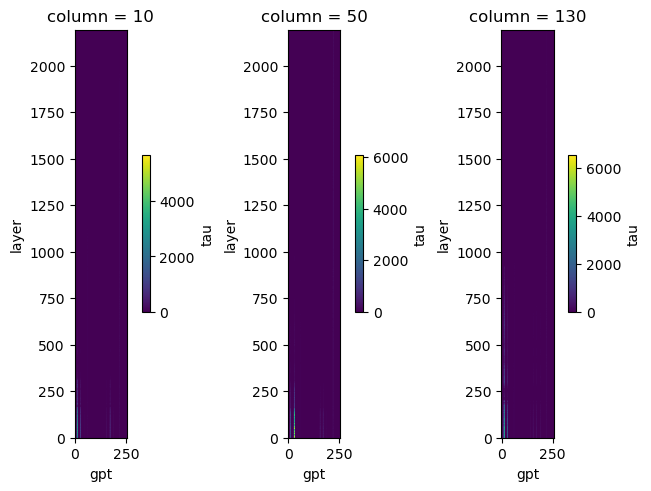

In [26]:
thick = optical_props_lw.tau

fig, ax = plt.subplots(1,3, constrained_layout=True)

thick.isel(column=10).plot(ax=ax[0], x="gpt", y="layer")
thick.isel(column=50).plot(ax=ax[1], x="gpt", y="layer")
thick.isel(column=130).plot(ax=ax[2], x="gpt", y="layer")

In [ ]:
optical_props_sw = gas_optics_sw.compute(
    atmosphere.drop_vars(["level", "column", "layer"]), 
    add_to_input=False,
)
optical_props_sw["surface_albedo_direct"] = 0.06
optical_props_sw["surface_albedo_diffuse"] = 0.06


# Could also specific a single "surface_albedo"
optical_props_sw["mu0"] = atmosphere.mu0.drop_vars("column")
optical_props_sw

<xarray.Dataset> Size: 2GB
Dimensions:                 (column: 137, gpt: 224, layer: 2195, bnd: 14,
                             pair: 2)
Coordinates:
  * column                  (column) int64 1kB 0 1 2 3 4 ... 132 133 134 135 136
Dimensions without coordinates: gpt, layer, bnd, pair
Data variables:
    toa_source              (column, gpt) float64 246kB 1.994 1.938 ... 0.001233
    tau                     (layer, gpt, column) float64 539MB 0.0005288 ... ...
    ssa                     (layer, gpt, column) float64 539MB 6.213e-05 ... ...
    g                       (layer, gpt, column) float64 539MB 0.0 0.0 ... 0.0
    bnd_limits_gpt          (bnd, pair) int32 112B 1 16 17 32 ... 208 209 224
    surface_albedo_direct   float64 8B 0.06
    surface_albedo_diffuse  float64 8B 0.06
    mu0                     (column) float64 1kB 0.5 0.0 0.866 ... 0.0 0.0 0.0
Attributes:
    description:  Spectrally-dependent quiet sun irradiance from the NRLSSI2 ...
    top_at_1:     <xarray.DataArray 'pres_layer' ()> Size: 1B\narray(False)

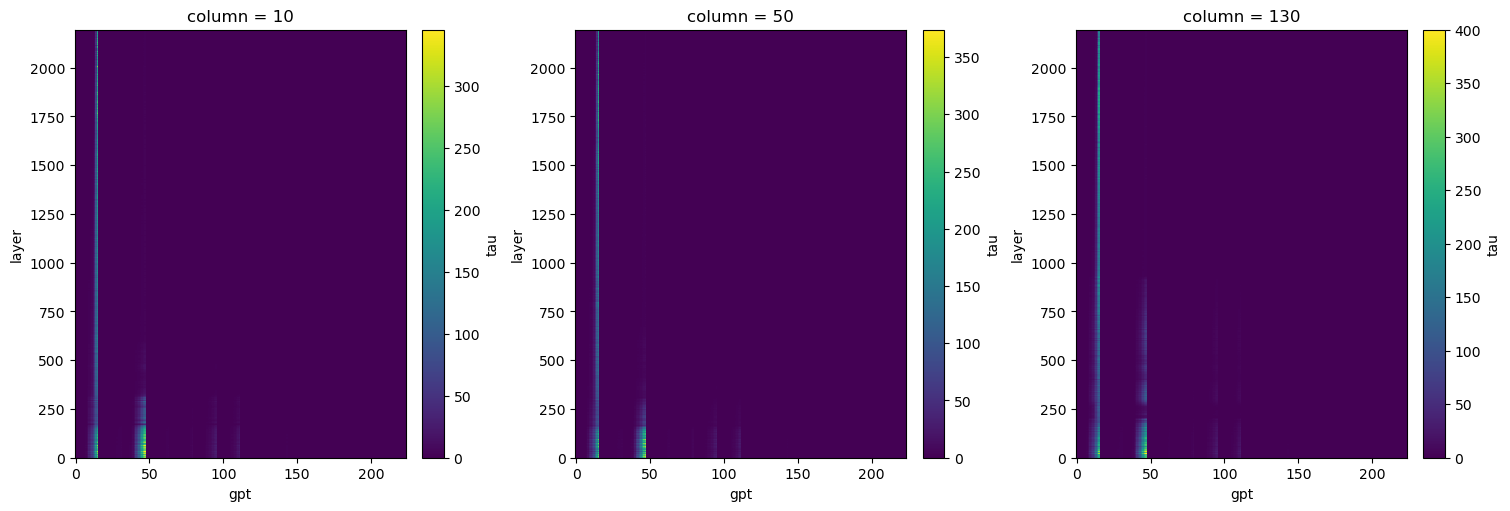

In [28]:
thick = optical_props_sw.tau

fig, ax = plt.subplots(1,3, figsize=(15,5), constrained_layout=True)

thick.isel(column=10).plot(ax=ax[0], x="gpt", y="layer")
thick.isel(column=50).plot(ax=ax[1], x="gpt", y="layer")
thick.isel(column=130).plot(ax=ax[2], x="gpt", y="layer")

compute fluxes

In [ ]:
fluxes_lw = optical_props_lw.rte.solve(add_to_input=False)
fluxes_lw = fluxes_lw.assign_coords({"column":atmosphere.column, "level":atmosphere.level})
fluxes_lw

<xarray.Dataset> Size: 5MB
Dimensions:       (column: 137, level: 2196)
Coordinates:
  * column        (column) datetime64[ns] 1kB 2020-01-16T20:53:46 ... 2020-02...
  * level         (level) int16 4kB 50 60 70 80 90 ... 21970 21980 21990 22000
Data variables:
    lw_flux_up    (column, level) float64 2MB 459.9 458.2 457.7 ... 304.0 304.0
    lw_flux_down  (column, level) float64 2MB 352.8 352.2 351.5 ... 0.3274 0.0

In [ ]:
fluxes_sw = optical_props_sw.rte.solve(add_to_input=False)
fluxes_sw = fluxes_sw.assign_coords({"column":atmosphere.column, "level":atmosphere.level})
fluxes_sw

<xarray.Dataset> Size: 7MB
Dimensions:       (column: 137, level: 2196)
Coordinates:
  * column        (column) datetime64[ns] 1kB 2020-01-16T20:53:46 ... 2020-02...
  * level         (level) int16 4kB 50 60 70 80 90 ... 21970 21980 21990 22000
Data variables:
    sw_flux_up    (column, level) float64 2MB 30.02 30.05 30.09 ... 0.0 0.0 0.0
    sw_flux_down  (column, level) float64 2MB 500.3 500.5 500.7 ... 0.0 0.0 0.0
    sw_flux_dir   (column, level) float64 2MB 454.0 454.3 454.5 ... 0.0 0.0 0.0

preliminary results

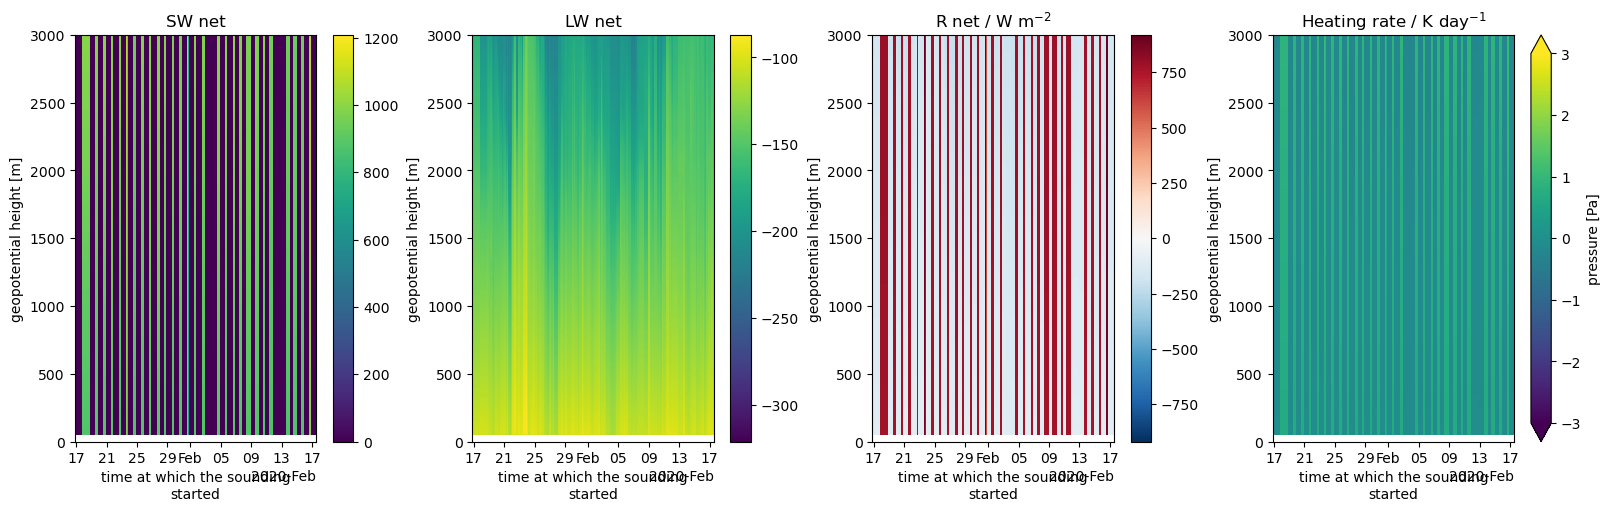

In [29]:
fig, ax = plt.subplots(1, 4, figsize=(16,5), constrained_layout=True)

(fluxes_sw.sw_flux_down - fluxes_sw.sw_flux_up).plot(ax=ax[0], y="level")
ax[0].set_title("SW net")

(fluxes_lw.lw_flux_down - fluxes_lw.lw_flux_up).plot(ax=ax[1], y="level")
ax[1].set_title("LW net")

Rnet = fluxes_lw.lw_flux_down - fluxes_lw.lw_flux_up + fluxes_sw.sw_flux_down - fluxes_sw.sw_flux_up
(Rnet).plot(ax=ax[2], y="level")
ax[2].set_title(r"R net / $\rm W~m^{-2}$")

cp = 1004.
heating_rate = Rnet / (atmosphere.rho_level * cp)
(heating_rate).plot(ax=ax[3], y="level", vmin=-3, vmax=3)
ax[3].set_title(r"Heating rate / $\rm K~day^{-1}$")


for x in ax:
    x.set_ylim(0,3000)


In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(16,5), constrained_layout=True)
sw_net = fluxes_sw.sw_flux_down - fluxes_sw.sw_flux_up
(sw_net.groupby(column="1h")).plot(ax=ax[0], y="level")
ax[0].set_title("SW net")

(fluxes_lw.lw_flux_down - fluxes_lw.lw_flux_up).plot(ax=ax[1], y="level")
ax[1].set_title("LW net")

Rnet = fluxes_lw.lw_flux_down - fluxes_lw.lw_flux_up + fluxes_sw.sw_flux_down - fluxes_sw.sw_flux_up
(Rnet).plot(ax=ax[2], y="level")
ax[2].set_title(r"R net / $\rm W~m^{-2}$")

-130.10813616635045

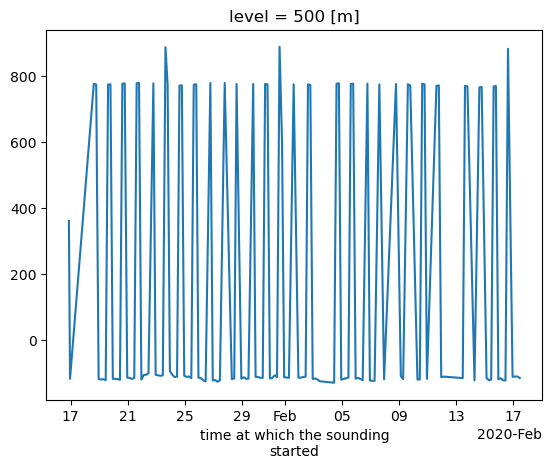

In [21]:
Rnet.sel(level=500).plot()
Rnet.sel(level=500).min().item()

(array([2.65494996e-07, 5.08490416e-07, 6.08306716e-07, 7.46849560e-07,
        1.13847854e-06, 2.16800459e-06, 4.48089282e-06, 1.93823620e-06,
        1.52642578e-06, 1.30054367e-06, 8.13461941e-07, 5.42580683e-07,
        4.04719645e-07, 2.94267181e-07, 2.35563742e-07, 1.98064449e-07,
        1.74201262e-07, 1.52928936e-07, 1.35679261e-07, 1.25793084e-07,
        1.05884368e-07, 6.11579382e-08, 5.42035238e-08, 5.16808441e-08,
        5.12717609e-08, 4.77945537e-08, 4.01583340e-08, 3.79083764e-08,
        3.55902383e-08, 2.17495901e-08]),
 array([-400625.74448969, -345880.368756  , -291134.99302231,
        -236389.61728862, -181644.24155493, -126898.86582124,
         -72153.49008755,  -17408.11435386,   37337.26137984,
          92082.63711353,  146828.01284722,  201573.38858091,
         256318.7643146 ,  311064.14004829,  365809.51578198,
         420554.89151567,  475300.26724936,  530045.64298305,
         584791.01871674,  639536.39445044,  694281.77018413,
         749027.1459

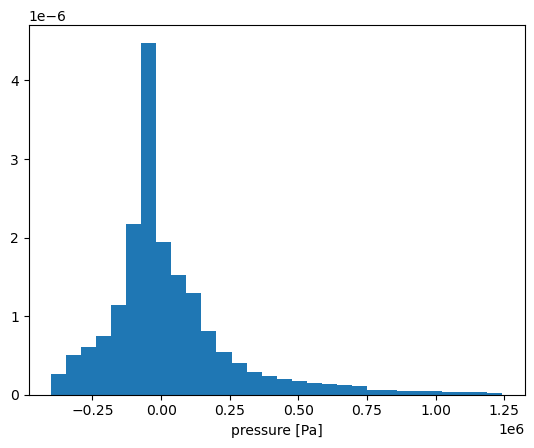

In [48]:
(heating_rate*86400).plot.hist(bins=30, density=True)

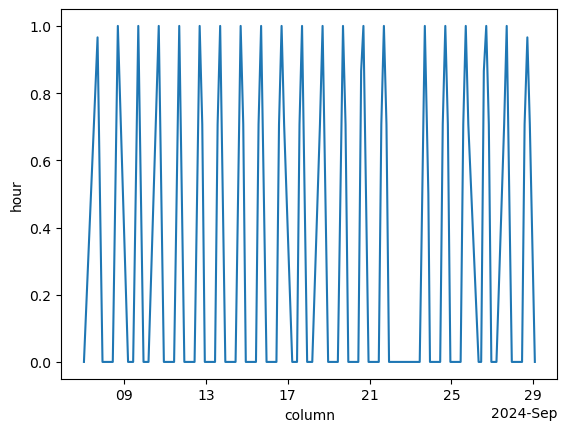

In [25]:
mu0_(first_col.column.dt.hour).plot()
